In [88]:
!pip install -q dandi remfile pynwb h5py scikit-learn caveclient pandas matplotlib seaborn

import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
import remfile
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from dandi.dandiapi import DandiAPIClient
from caveclient import CAVEclient
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')

client = CAVEclient()
client.auth.save_token(token="e224f23102e20dafba62dafc29f1a08d", overwrite=True)
client = CAVEclient("minnie65_public")

In [46]:
def extract_nwb_metadata(asset_path):
    print(f"Streaming metadata from: {asset_path}")
    client_dandi = DandiAPIClient()
    dandiset = client_dandi.get_dandiset("000402", "draft")
    asset = next(a for a in dandiset.get_assets() if asset_path in a.path)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    h5 = h5py.File(remfile.File(s3_url), "r")
    metadata = []

    # Only check the planes that have coregistered CAVE IDs
    for i in [2, 4, 6, 8]:
        seg_path = f"processing/ophys/ImageSegmentation/PlaneSegmentation{i}"

        # Get raw root IDs just to filter out the NaNs (unregistered neurons)
        pt_root_ids_raw = h5[seg_path]["pt_root_id"][:]
        valid_mask = ~np.isnan(pt_root_ids_raw)
        valid_indices = np.where(valid_mask)[0]

        # Extract the immutable Supervoxel IDs and physical coordinates
        pt_supervoxels = h5[seg_path]["pt_supervoxel_id"][:][valid_indices]
        x_pos = h5[seg_path]["pt_x_position"][:][valid_indices]
        y_pos = h5[seg_path]["pt_y_position"][:][valid_indices]
        z_pos = h5[seg_path]["pt_z_position"][:][valid_indices]

        for idx, sv_id in enumerate(pt_supervoxels):
            metadata.append({
                'session': asset_path,
                'plane': i,
                'pt_supervoxel_id': int(sv_id),
                'nwb_x': x_pos[idx],
                'nwb_y': y_pos[idx],
                'nwb_z': z_pos[idx]
            })

    return pd.DataFrame(metadata)

# We are starting with session 7, scan 4.
target_session = "ses-4-scan-7"
nwb_df = extract_nwb_metadata(target_session)

print(f"\nExtracted {len(nwb_df)} coregistered neurons.")
display(nwb_df.head(10))

Streaming metadata from: ses-4-scan-7

Extracted 685 coregistered neurons.


,session,plane,pt_supervoxel_id,nwb_x,nwb_y,nwb_z
0,ses-4-scan-7,2,105487283075448384,296167.0,94711.0,15794.0
1,ses-4-scan-7,2,101758289725398432,269248.0,98832.0,18382.0
2,ses-4-scan-7,2,102391814782283808,273716.0,100363.0,19517.0
3,ses-4-scan-7,2,102531727972419184,274864.0,94064.0,22046.0
4,ses-4-scan-7,2,100491446037107984,259731.0,97037.0,16967.0
5,ses-4-scan-7,2,98661721048714608,246403.0,96034.0,15863.0
6,ses-4-scan-7,2,97676765526421840,239360.0,97728.0,21115.0
7,ses-4-scan-7,2,95003096107059872,219904.0,100512.0,15677.0
8,ses-4-scan-7,2,95073946021845424,220240.0,103936.0,16736.0
9,ses-4-scan-7,2,96761971986367024,232864.0,97872.0,22184.0


/tmp/ipython-input-1548200522.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=nwb_df, x='layer', order=['L2/3', 'L4', 'L5', 'L6'], palette='viridis')


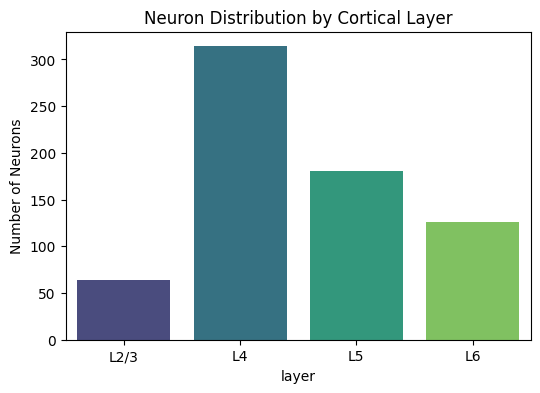

In [47]:
"""
Assigning cortical layers
Plane 2 (~80um) -> Layer 2/3
Plane 4 (~220um) -> Layer 4
Plane 6 (~360um) -> Layer 5
Plane 8 (~500um) -> Layer 6
"""

layer_mapping = {2: 'L2/3', 4: 'L4', 6: 'L5', 8: 'L6'}
nwb_df['layer'] = nwb_df['plane'].map(layer_mapping)

# Plot the distribution of neurons across layers
plt.figure(figsize=(6, 4))
sns.countplot(data=nwb_df, x='layer', order=['L2/3', 'L4', 'L5', 'L6'], palette='viridis')
plt.title("Neuron Distribution by Cortical Layer")
plt.ylabel("Number of Neurons")
plt.show()

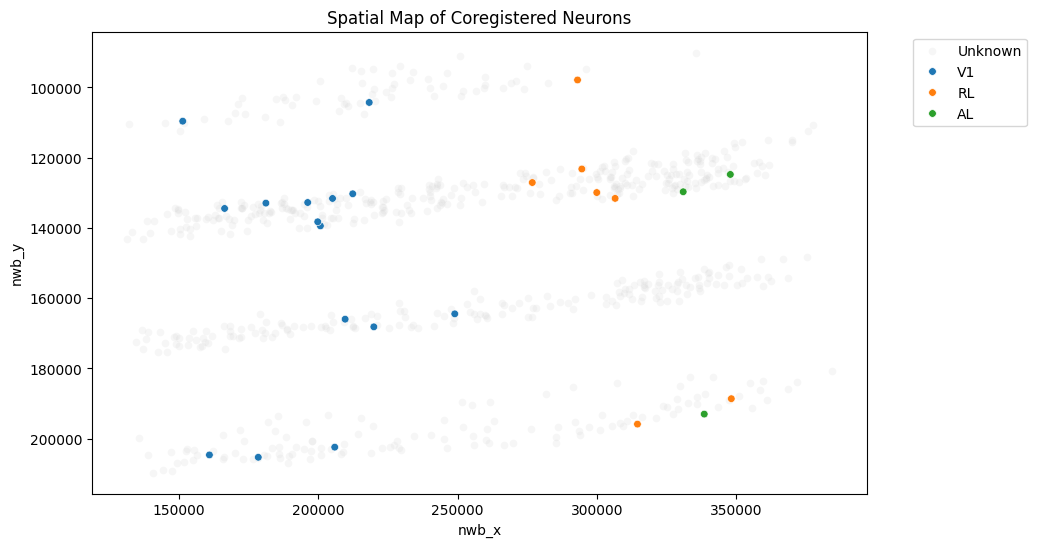

Current Missing Areas:
visual_area
Unknown    660
V1          15
RL           7
AL           3
Name: count, dtype: Int64


In [54]:
"""
Merging cave client neuron area info with dandi
"""

# Get Area table
area_df = client.materialize.query_table('nucleus_functional_area_assignment')

#  Get the BROAD cell types table
cell_class_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')

# Merge Area (LEFT join)
df_merged = pd.merge(nwb_df, area_df[['pt_supervoxel_id', 'tag']], on='pt_supervoxel_id', how='left')
df_merged = df_merged.rename(columns={'tag': 'visual_area'})
df_merged['visual_area'] = df_merged['visual_area'].fillna('Unknown')

# Merge Cell Type (LEFT join)
df_merged = pd.merge(df_merged, cell_class_df[['pt_supervoxel_id', 'classification_system', 'cell_type']], on='pt_supervoxel_id', how='left')

# PLOT: Before KNN
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged[df_merged['visual_area'] == 'Unknown'],
    x='nwb_x', y='nwb_y', color='lightgrey', label='Unknown', s=30, alpha=0.2
)
sns.scatterplot(
    data=df_merged[df_merged['visual_area'] != 'Unknown'],
    x='nwb_x', y='nwb_y', hue='visual_area', s=30, alpha=1.0
)

plt.title("Spatial Map of Coregistered Neurons")
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Current Missing Areas:")
print(df_merged['visual_area'].value_counts())

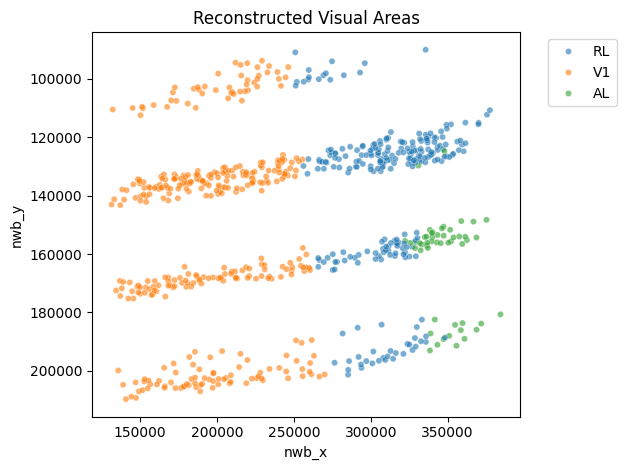


 Matrix with all Metadata


,session,plane,depth (um),pt_supervoxel_id,nwb_x,nwb_y,nwb_z,visual_area,layer,classification_system,cell_type
0,ses-4-scan-7,2,80,105487283075448384,296167.0,94711.0,15794.0,RL,L2/3,<NA>,<NA>
1,ses-4-scan-7,2,80,101758289725398432,269248.0,98832.0,18382.0,RL,L2/3,<NA>,<NA>
2,ses-4-scan-7,2,80,102391814782283808,273716.0,100363.0,19517.0,RL,L2/3,<NA>,<NA>
3,ses-4-scan-7,2,80,102531727972419184,274864.0,94064.0,22046.0,RL,L2/3,<NA>,<NA>
4,ses-4-scan-7,2,80,100491446037107984,259731.0,97037.0,16967.0,RL,L2/3,<NA>,<NA>
5,ses-4-scan-7,2,80,98661721048714608,246403.0,96034.0,15863.0,V1,L2/3,<NA>,<NA>
6,ses-4-scan-7,2,80,97676765526421840,239360.0,97728.0,21115.0,V1,L2/3,<NA>,<NA>
7,ses-4-scan-7,2,80,95003096107059872,219904.0,100512.0,15677.0,V1,L2/3,<NA>,<NA>
8,ses-4-scan-7,2,80,95073946021845424,220240.0,103936.0,16736.0,V1,L2/3,<NA>,<NA>
9,ses-4-scan-7,2,80,96761971986367024,232864.0,97872.0,22184.0,V1,L2/3,<NA>,<NA>


In [68]:
"""
Using KNN to classify the unknown neurons
"""
known_mask = df_merged['visual_area'] != 'Unknown'
unknown_mask = df_merged['visual_area'] == 'Unknown'

# Train KNN on neurons that have official labels
X_train = df_merged.loc[known_mask, ['nwb_x', 'nwb_y']]
y_train = df_merged.loc[known_mask, 'visual_area']

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict the 'Unknown' neurons
X_unknown = df_merged.loc[unknown_mask, ['nwb_x', 'nwb_y']]
predicted_areas = knn.predict(X_unknown)

# Apply predictions to the dataframe
df_final = df_merged.copy()
df_final.loc[unknown_mask, 'visual_area'] = predicted_areas


# Plot knn reconstruction
sns.scatterplot(
    data=df_final,
    x='nwb_x',
    y='nwb_y',
    hue='visual_area',
    s=20,
    alpha=0.6
)
plt.title("Reconstructed Visual Areas")
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Add Physical Imaging Depth (um)
depth_mapping = {2: 80, 4: 220, 6: 360, 8: 500}
df_final['depth (um)'] = df_final['plane'].map(depth_mapping)

# Clean up column order
final_columns = ['session', 'plane', 'depth (um)', 'pt_supervoxel_id',
                 'nwb_x', 'nwb_y', 'nwb_z', 'visual_area', 'layer',
                 'classification_system', 'cell_type']
df_final = df_final[final_columns]

# Save to csv for future use
df_final.to_csv(f"{target_session}_master_metadata.csv", index=False)

print("\n Matrix with all Metadata")
display(df_final.head(10))

In [77]:
"""
Mapping fluorescence to the coregistered neurons from cave
"""

# Connect to DANDI
target_session = "ses-4-scan-7"
client_dandi = DandiAPIClient()
asset = next(a for a in client_dandi.get_dandiset("000402", "draft").get_assets() if target_session in a.path)
s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
h5 = h5py.File(remfile.File(s3_url), "r")
nwb = NWBHDF5IO(file=h5, load_namespaces=True).read()

# Get Movie Clip Timings
clip_intervals = nwb.intervals['Clip']
starts = np.array(clip_intervals.start_time[:])
stops = np.array(clip_intervals.stop_time[:])

# Get Continuous Data (Plane 2)
ophys = nwb.processing["ophys"]
fluo = ophys.data_interfaces["Fluorescence"]
rrs2 = fluo.roi_response_series["RoiResponseSeries2"]
ts = rrs2.timestamps[:]

# This uses df_final to grab the correct data
all_X_planes = []
ordered_metadata = []


for p in [2, 4, 6, 8]:
    # Filter our map for neurons in THIS plane
    plane_df = df_final[df_final['plane'] == p]
    if plane_df.empty: continue

    # Find the raw indices in the NWB file for these specific neurons
    seg_path = f"processing/ophys/ImageSegmentation/PlaneSegmentation{p}"
    raw_sv_ids = h5[seg_path]["pt_supervoxel_id"][:]

    # Match our filtered supervoxels back to their positions in the raw array
    # This is like finding the correct row in a massive database
    valid_indices = [np.where(raw_sv_ids == sv)[0][0] for sv in plane_df['pt_supervoxel_id']]

    # Pull the continuous activity for ONLY these valid indices
    rrs_name = f"RoiResponseSeries{p}"
    continuous_data = fluo.roi_response_series[rrs_name].data[:, valid_indices]

    # Slice into trials and calculate Mean Fluorescence per clip
    plane_trial_means = []
    for start, stop in zip(starts, stops):
        s_idx, e_idx = np.searchsorted(ts, [start, stop])
        # We take the mean across the time dimension (axis 0)
        plane_trial_means.append(np.mean(continuous_data[s_idx:e_idx, :], axis=0))

    # Stack trials: (n_trials, n_neurons_in_this_plane)
    all_X_planes.append(np.vstack(plane_trial_means))
    ordered_metadata.append(plane_df)

#  Build the Final X Matrix (Features)
# Shape: (384 trials, Total Mapped Neurons)
X_matrix = np.hstack(all_X_planes)

# Re-sync your df_final to match the column order of X_scaled
df_final = pd.concat(ordered_metadata, ignore_index=True)

print(f" X_matrix shape: {X_matrix.shape}")

 X_matrix shape: (384, 685)


In [71]:
print(clip_intervals.to_dataframe().columns.tolist())
print(clip_intervals.to_dataframe().head())

['start_time', 'stop_time', 'stimulus_type', 'condition_hash', 'movie_name', 'short_movie_name', 'duration']
    start_time  stop_time  stimulus_type        condition_hash  \
id                                                               
0    18.852491  28.819004  stimulus.Clip  JEL5/i5FccX4ykUOKaDW   
1    28.918990  38.885502  stimulus.Clip  AAQ1HNKGrg1cIXlMw7nz   
2    38.985497  48.951997  stimulus.Clip  ksTS42zV+O0YJqa0+s4Y   
3    49.051992  59.018496  stimulus.Clip  m5JLObtSRnbRKw1ukcSE   
4    59.118487  69.084989  stimulus.Clip  L8Z/mji+v1WipuJe4GaL   

                                           movie_name short_movie_name  \
id                                                                       
0   2 of 2 - 2011 ICup Cholla Challenge XC Mountai...         sports1m   
1                                   The Matrix (1999)        Cinematic   
2   2012 August 14 Midweek MTB Solitude XC Mountai...         sports1m   
3                                    2011 Comp Season     

In [94]:
"""
Decoding
"""

clip_df = clip_intervals.to_dataframe()
y = clip_df['short_movie_name'].values

n_classes = len(np.unique(y))
chance = 1 / n_classes
class_names = np.unique(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=135)),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, solver='saga', multi_class='multinomial'))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=135)),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=135)),
        ('clf', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                              early_stopping=False, random_state=42))
    ])
}

In [95]:
results = {}
predictions = {}

for name, model in models.items():
    scores = cross_val_score(model, X_matrix, y, cv=cv, scoring='accuracy')
    y_pred = cross_val_predict(model, X_matrix, y, cv=cv)
    results[name] = scores
    predictions[name] = y_pred
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")


Logistic Regression: 0.682 ± 0.052
SVM: 0.601 ± 0.065
Random Forest: 0.580 ± 0.076
MLP: 0.638 ± 0.066


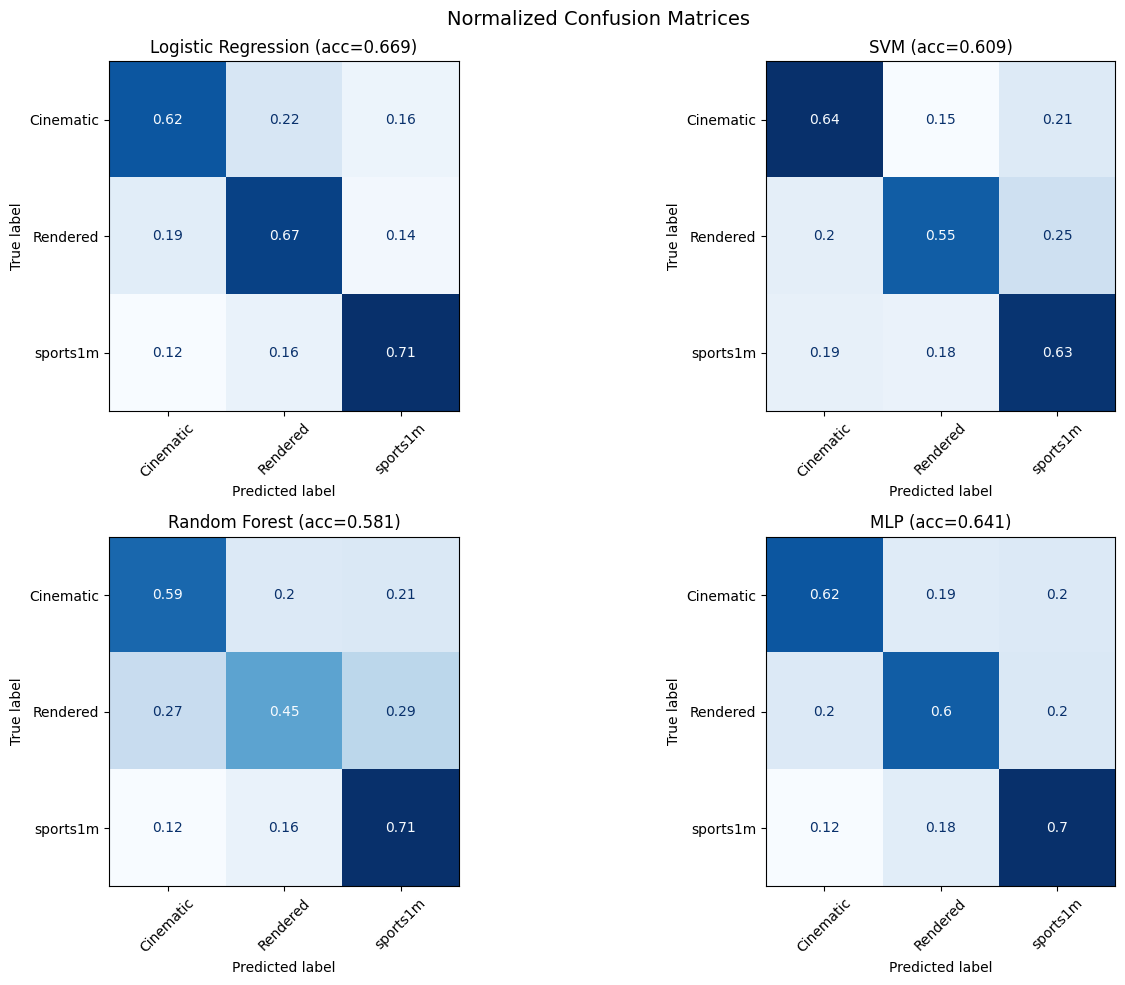

In [96]:
"""
Confusion Matrices
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, y_pred) in zip(axes.flatten(), predictions.items()):
    cm = confusion_matrix(y, y_pred, labels=class_names, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{name} (acc={np.mean(y == y_pred):.3f})')
plt.suptitle('Normalized Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

In [97]:
def decode_subpopulation(X_sub, y, label, min_neurons=10):
    if X_sub.shape[1] < min_neurons:
        print(f"  Skipping {label}: only {X_sub.shape[1]} neurons")
        return None
    # Scale n_components to subpopulation size, cap at 135
    n_components = min(135, X_sub.shape[1] - 1)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, solver='saga', multi_class='multinomial'))
    ])
    scores = cross_val_score(pipe, X_sub, y, cv=cv, scoring='accuracy')
    print(f"  {label}: {scores.mean():.3f} ± {scores.std():.3f}  (n={X_sub.shape[1]} neurons)")
    return {'label': label, 'mean': scores.mean(), 'std': scores.std(), 'n_neurons': X_sub.shape[1]}

decoding_results = []

print("By Visual Area")
for area in sorted(df_final['visual_area'].unique()):
    mask = (df_final['visual_area'] == area).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation(X_sub, y, area)
    if result:
        result['grouping'] = 'visual_area'
        decoding_results.append(result)

print("\nBy Imaging Depth")
for depth in sorted(df_final['depth (um)'].unique()):
    mask = (df_final['depth (um)'] == depth).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation(X_sub, y, f"{depth}um")
    if result:
        result['grouping'] = 'depth'
        decoding_results.append(result)

print("\n By Visual Area × Depth")
for (area, depth), grp in df_final.groupby(['visual_area', 'depth (um)']):
    mask = ((df_final['visual_area'] == area) & (df_final['depth (um)'] == depth)).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation(X_sub, y, f"{area}@{depth}um")
    if result:
        result['grouping'] = 'area_x_depth'
        result['area'] = area
        result['depth'] = depth
        decoding_results.append(result)

results_df = pd.DataFrame(decoding_results)

By Visual Area
  AL: 0.536 ± 0.056  (n=51 neurons)
  RL: 0.669 ± 0.053  (n=256 neurons)
  V1: 0.617 ± 0.036  (n=378 neurons)

By Imaging Depth
  80um: 0.456 ± 0.038  (n=64 neurons)
  220um: 0.614 ± 0.051  (n=314 neurons)
  360um: 0.578 ± 0.039  (n=181 neurons)
  500um: 0.588 ± 0.102  (n=126 neurons)

 By Visual Area × Depth
  Skipping AL@220um: only 2 neurons
  AL@360um: 0.515 ± 0.031  (n=35 neurons)
  AL@500um: 0.461 ± 0.071  (n=14 neurons)
  RL@80um: 0.406 ± 0.025  (n=16 neurons)
  RL@220um: 0.599 ± 0.073  (n=156 neurons)
  RL@360um: 0.570 ± 0.021  (n=52 neurons)
  RL@500um: 0.521 ± 0.056  (n=32 neurons)
  V1@80um: 0.502 ± 0.063  (n=48 neurons)
  V1@220um: 0.583 ± 0.050  (n=156 neurons)
  V1@360um: 0.484 ± 0.077  (n=94 neurons)
  V1@500um: 0.539 ± 0.067  (n=80 neurons)


In [98]:
pca_check = PCA().fit(StandardScaler().fit_transform(X_matrix))
cumvar = np.cumsum(pca_check.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"90% variance: {n_90} components")
print(f"95% variance: {n_95} components")

90% variance: 135 components
95% variance: 190 components


In [93]:
print(df_final.groupby(['visual_area', 'depth (um)']).size().unstack(fill_value=0))

depth (um)   80   220  360  500
visual_area                    
AL             0    2   35   14
RL            16  156   52   32
V1            48  156   94   80


In [100]:
"""
Decoding based on depth/area
"""

def decode_subpopulation_perclip(X_sub, y, label, min_neurons=10):
    if X_sub.shape[1] < min_neurons:
        return None

    n_components = min(135, X_sub.shape[1] - 1)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, solver='saga', multi_class='multinomial'))
    ])

    y_pred = cross_val_predict(pipe, X_sub, y, cv=cv)

    # Per-clip accuracy
    per_clip = {}
    for clip in class_names:
        mask = y == clip
        per_clip[clip] = np.mean(y_pred[mask] == clip)

    return {'label': label, **per_clip}

# By Visual Area
area_clip_results = []
for area in sorted(df_final['visual_area'].unique()):
    mask = (df_final['visual_area'] == area).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation_perclip(X_sub, y, area)
    if result:
        area_clip_results.append(result)

area_clip_df = pd.DataFrame(area_clip_results).set_index('label')

#By Depth
depth_clip_results = []
for depth in sorted(df_final['depth (um)'].unique()):
    mask = (df_final['depth (um)'] == depth).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation_perclip(X_sub, y, f"{depth}um")
    if result:
        depth_clip_results.append(result)

depth_clip_df = pd.DataFrame(depth_clip_results).set_index('label')

#By Area x Depth
area_depth_clip_results = []
for (area, depth), grp in df_final.groupby(['visual_area', 'depth (um)']):
    mask = ((df_final['visual_area'] == area) & (df_final['depth (um)'] == depth)).values
    X_sub = X_matrix[:, mask]
    result = decode_subpopulation_perclip(X_sub, y, f"{area}@{depth}um")
    if result:
        area_depth_clip_results.append(result)

area_depth_clip_df = pd.DataFrame(area_depth_clip_results).set_index('label')

print("Per-clip accuracy by Visual Area:")
display(area_clip_df.round(3))

print("\nPer-clip accuracy by Depth:")
display(depth_clip_df.round(3))

Per-clip accuracy by Visual Area:


,Cinematic,Rendered,sports1m
label,,,
AL,0.562,0.461,0.586
RL,0.680,0.617,0.711
V1,0.578,0.609,0.664



Per-clip accuracy by Depth:


,Cinematic,Rendered,sports1m
label,,,
80um,0.469,0.406,0.492
220um,0.570,0.555,0.719
360um,0.578,0.539,0.617
500um,0.633,0.531,0.602


In [102]:
"""
confusion matrix
"""

def decode_confusion_matrix(X_sub, y, label, min_neurons=10):
    if X_sub.shape[1] < min_neurons:
        return None, None

    n_components = min(135, X_sub.shape[1] - 1)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, solver='saga', multi_class='multinomial'))
    ])

    y_pred = cross_val_predict(pipe, X_sub, y, cv=cv)
    cm = confusion_matrix(y, y_pred, labels=class_names, normalize='true')
    return cm, y_pred

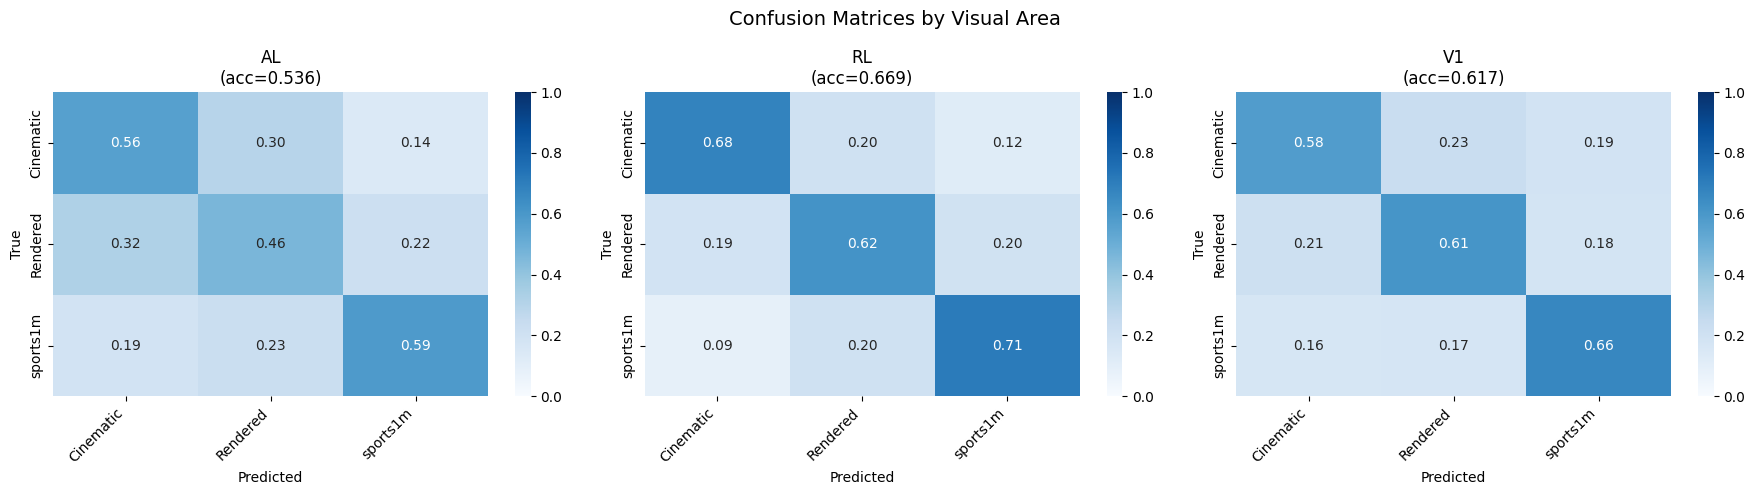

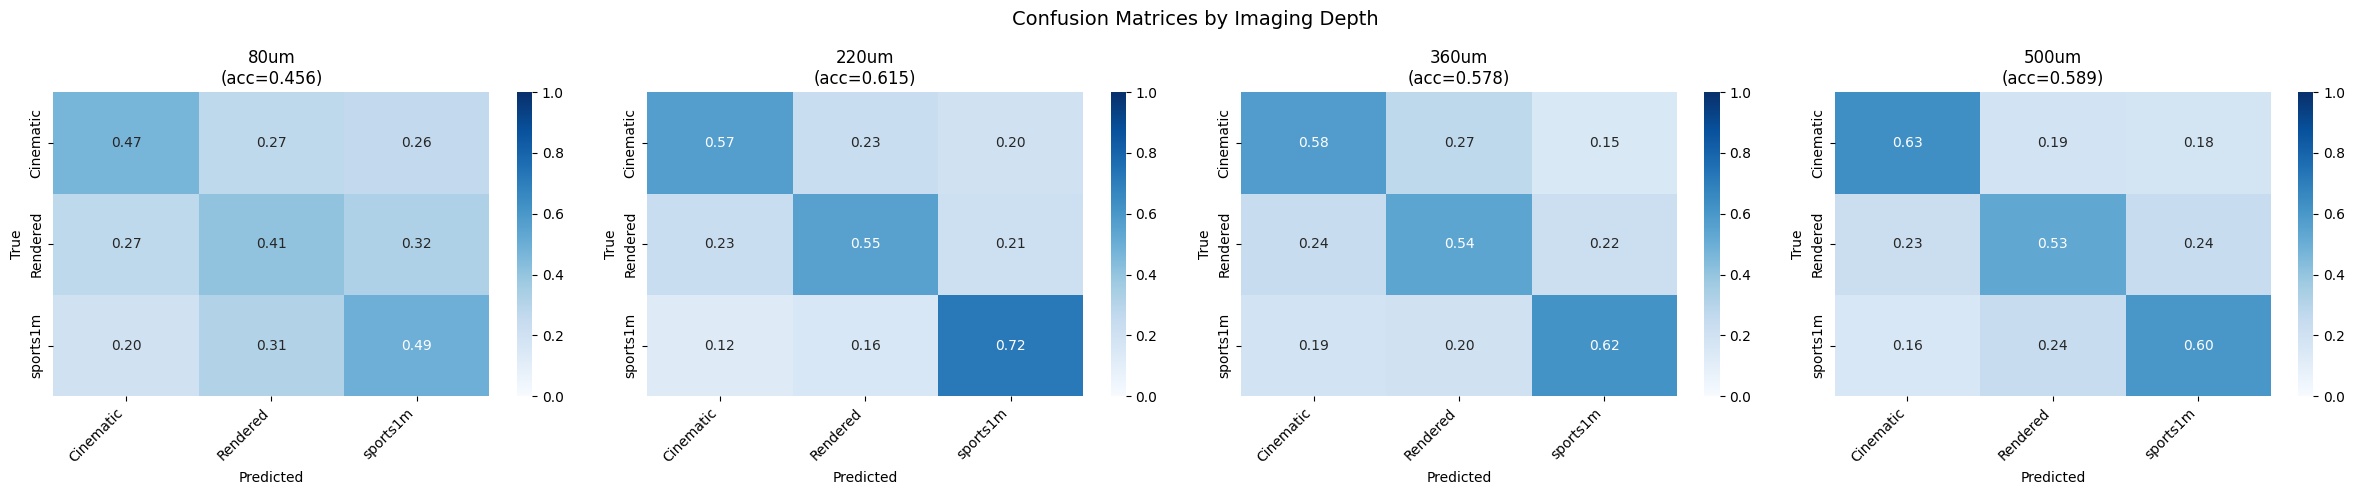

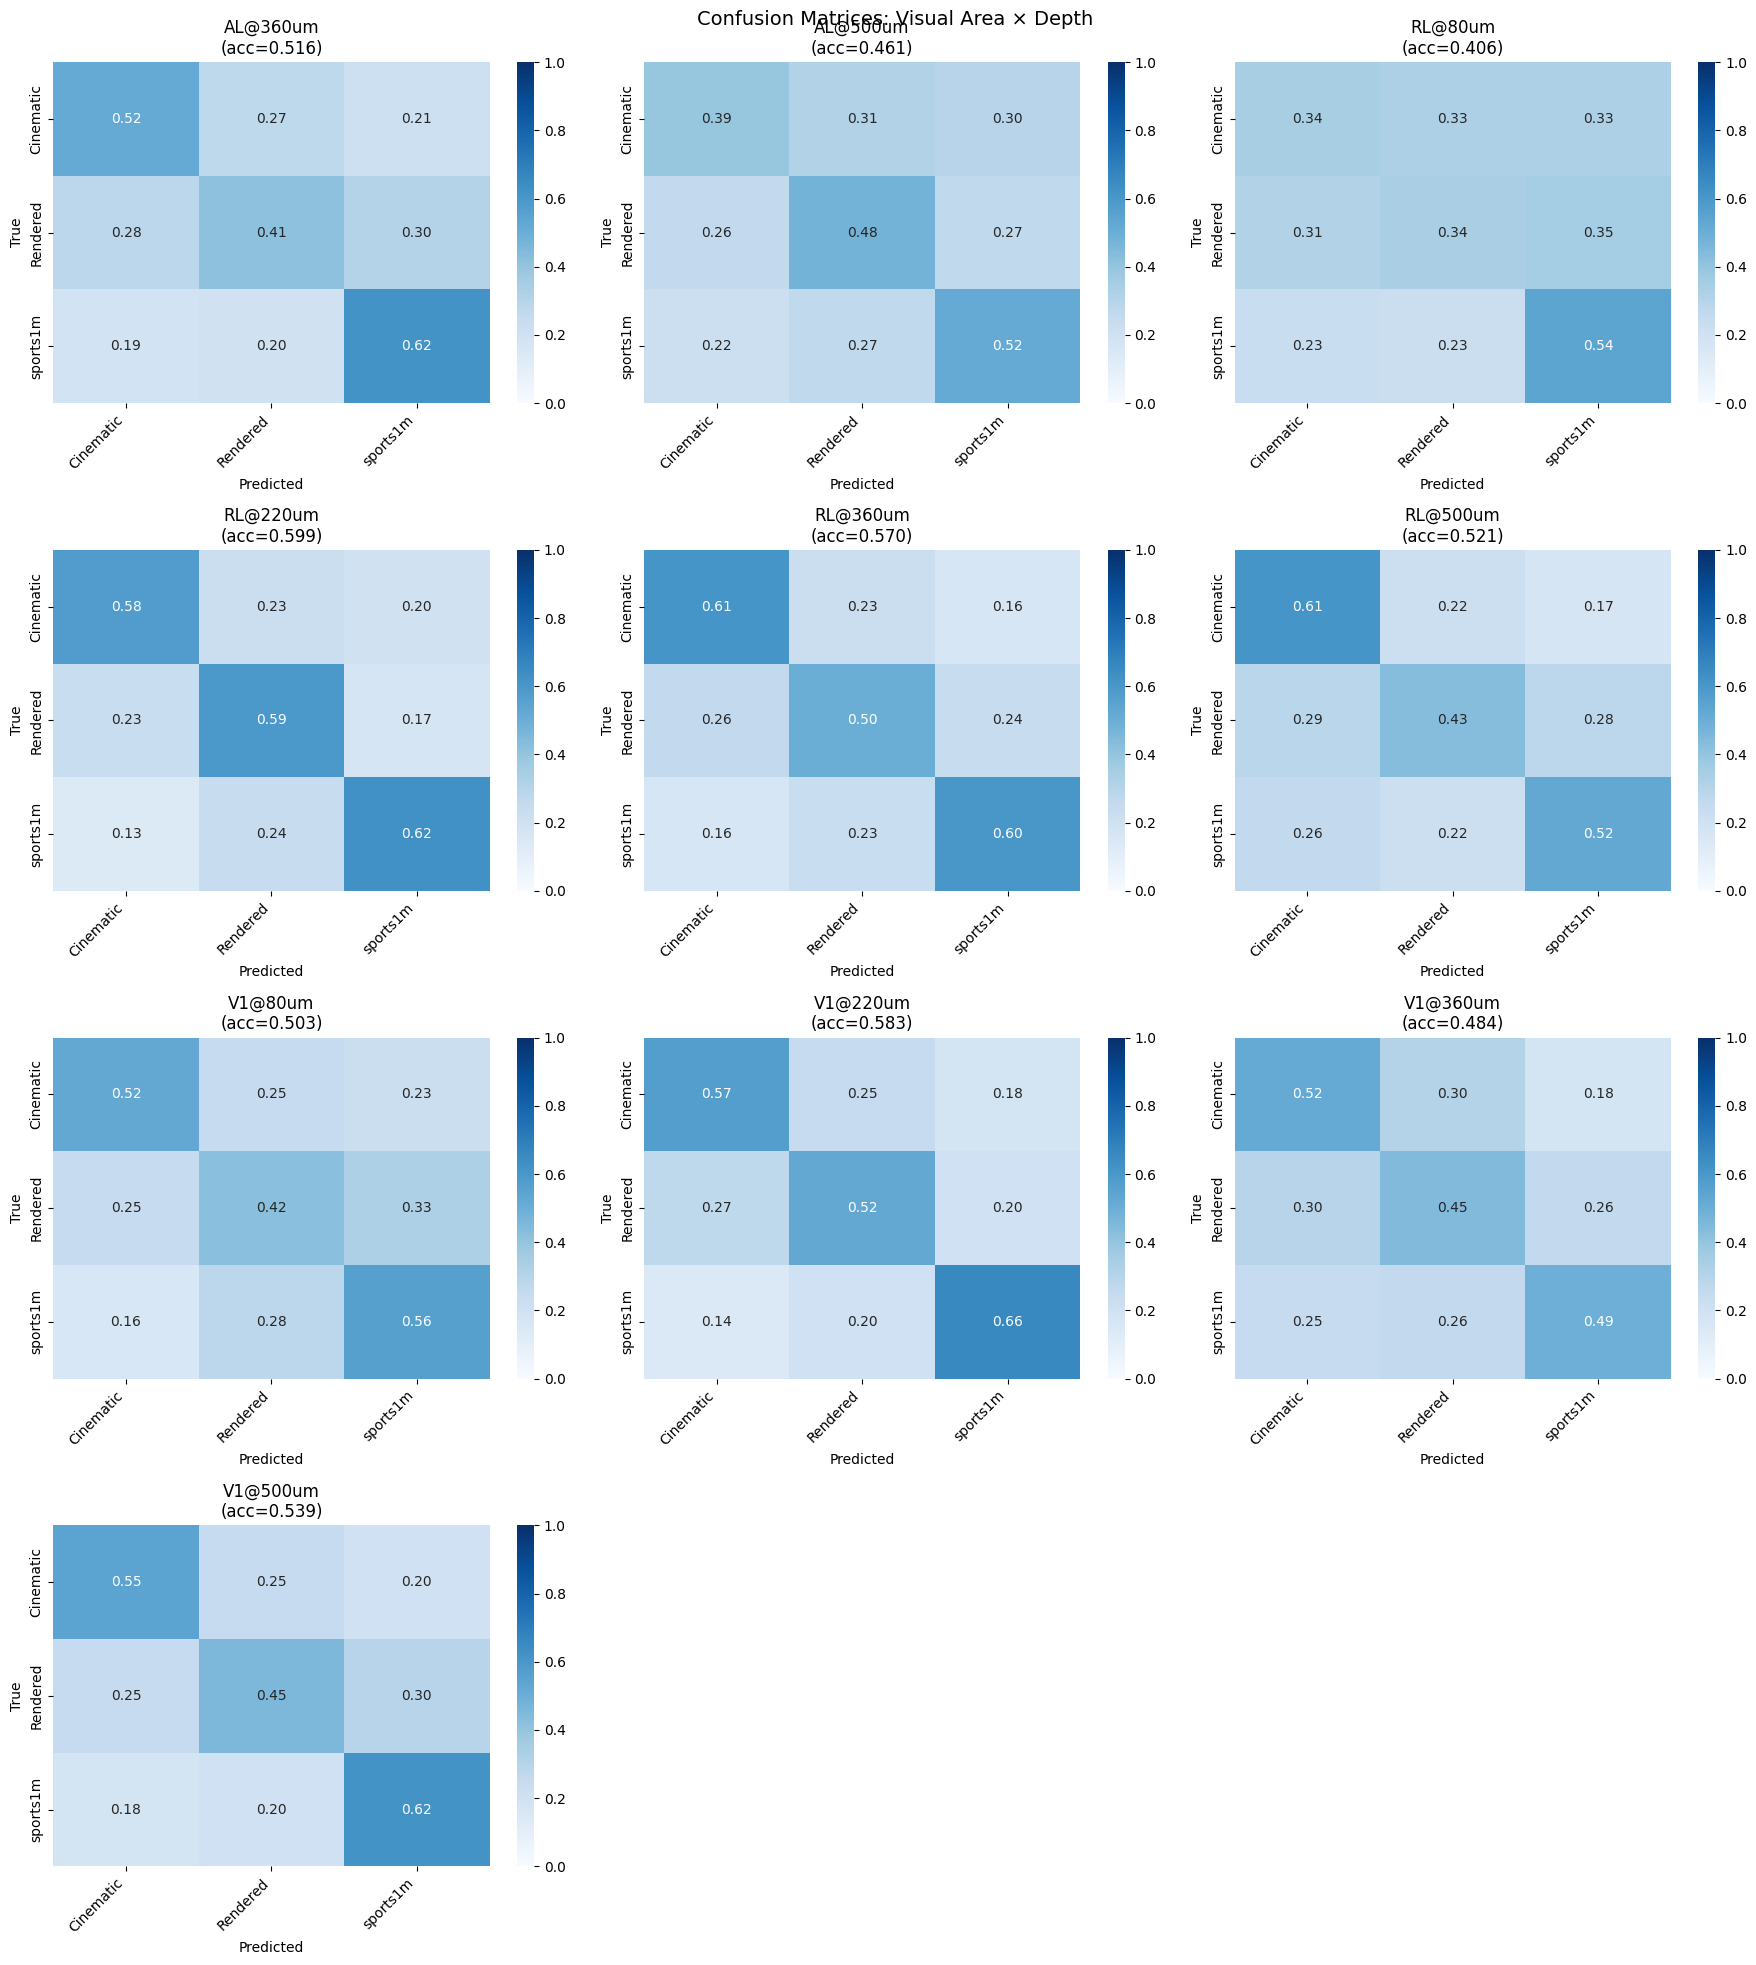

In [104]:
area_cms = {}
for area in sorted(df_final['visual_area'].unique()):
    mask = (df_final['visual_area'] == area).values
    X_sub = X_matrix[:, mask]
    cm, y_pred = decode_confusion_matrix(X_sub, y, area)
    if cm is not None:
        area_cms[area] = cm

fig, axes = plt.subplots(1, len(area_cms), figsize=(6 * len(area_cms), 5))
if len(area_cms) == 1:
    axes = [axes]
for ax, (area, cm) in zip(axes, area_cms.items()):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, ax=ax)
    ax.set_title(f'{area}\n(acc={np.diag(cm).mean():.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrices by Visual Area', fontsize=14)
plt.tight_layout()
plt.show()

depth_cms = {}
for depth in sorted(df_final['depth (um)'].unique()):
    mask = (df_final['depth (um)'] == depth).values
    X_sub = X_matrix[:, mask]
    cm, y_pred = decode_confusion_matrix(X_sub, y, f"{depth}um")
    if cm is not None:
        depth_cms[f"{depth}um"] = cm

fig, axes = plt.subplots(1, len(depth_cms), figsize=(6 * len(depth_cms), 5))
for ax, (depth, cm) in zip(axes, depth_cms.items()):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, ax=ax)
    ax.set_title(f'{depth}\n(acc={np.diag(cm).mean():.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrices by Imaging Depth', fontsize=14)
plt.tight_layout()
plt.show()

area_depth_cms = {}
for (area, depth), grp in df_final.groupby(['visual_area', 'depth (um)']):
    mask = ((df_final['visual_area'] == area) & (df_final['depth (um)'] == depth)).values
    X_sub = X_matrix[:, mask]
    cm, y_pred = decode_confusion_matrix(X_sub, y, f"{area}@{depth}um")
    if cm is not None:
        area_depth_cms[f"{area}@{depth}um"] = cm

n_plots = len(area_depth_cms)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, (label, cm) in zip(axes, area_depth_cms.items()):
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, ax=ax)
    ax.set_title(f'{label}\n(acc={np.diag(cm).mean():.3f})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Hide empty subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices: Visual Area × Depth', fontsize=14)
print()
plt.tight_layout()
plt.show()